# Regression — Category Recap

> **Goal:** predict a continuous target $y \in \mathbb{R}$ from features $x$.

This notebook ties together the seven regression notebooks
([01](illustrated_01_regression_linear.ipynb)–[07](illustrated_07_regression_gradient_boosting.ipynb))
into a single decision panel and a head-to-head benchmark on a shared dataset.

**Algorithms covered:**

| # | Algorithm | Notebook | One-line role |
|---|---|---|---|
| 01 | Linear (OLS) | [linear](illustrated_01_regression_linear.ipynb) | The baseline. Closed-form, interpretable, low variance. |
| 02 | Ridge | [ridge](illustrated_02_regression_ridge.ipynb) | OLS + $\ell_2$. Fixes multicollinearity. |
| 03 | Lasso | [lasso](illustrated_03_regression_lasso.ipynb) | OLS + $\ell_1$. Feature selection. |
| 04 | Locally Weighted | [lwr](illustrated_04_regression_locally_weighted.ipynb) | Non-parametric, refits per query. |
| 05 | Gaussian Process | [gp](illustrated_05_regression_gaussian_process.ipynb) | Bayesian, calibrated uncertainty. |
| 06 | Random Forest | [rf](illustrated_06_regression_random_forest.ipynb) | Variance-reducing tree ensemble. |
| 07 | Gradient Boosting | [gb](illustrated_07_regression_gradient_boosting.ipynb) | Bias-reducing tree ensemble. State-of-the-art on tabular. |


## Cheat-sheet — regression algorithm landscape

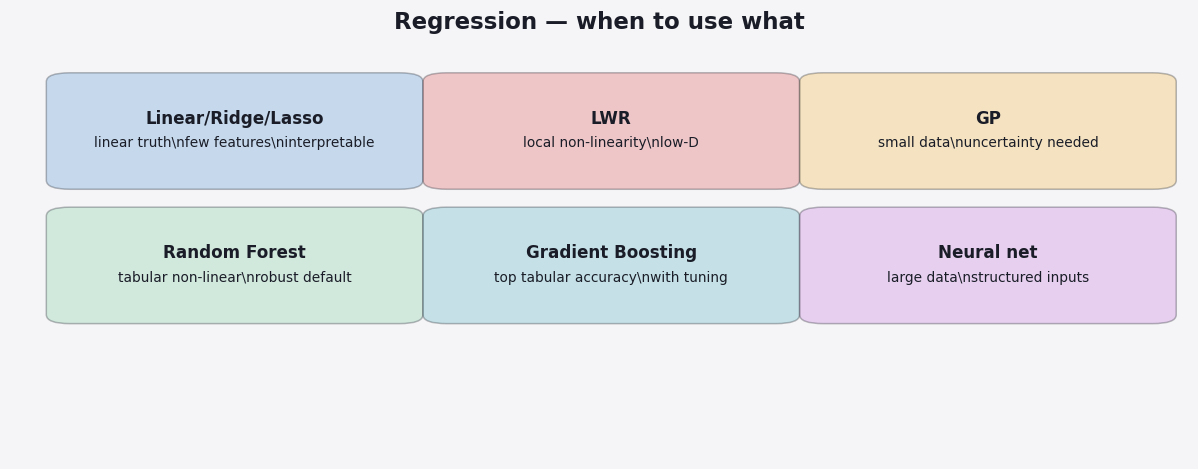

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 4.4)); ax.axis('off')
ax.text(0.5, 0.96, 'Regression — when to use what', ha='center', fontsize=15, weight='bold')
items = [('Linear/Ridge/Lasso', 'linear truth\\nfew features\\ninterpretable'), ('LWR', 'local non-linearity\\nlow-D'), ('GP', 'small data\\nuncertainty needed'), ('Random Forest', 'tabular non-linear\\nrobust default'), ('Gradient Boosting', 'top tabular accuracy\\nwith tuning'), ('Neural net', 'large data\\nstructured inputs')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Side-by-side comparison

| Property | OLS | Ridge | Lasso | LWR | GP | RF | GB |
|---|---|---|---|---|---|---|---|
| Linear in $x$? | ✅ | ✅ | ✅ | locally | depends on kernel | ❌ | ❌ |
| Handles $p \gg n$ | ❌ | ✅ | ✅ | ❌ | ✅ | ✅ | ✅ |
| Feature selection | ❌ | ❌ | ✅ | ❌ | ❌ | partial | partial |
| Calibrated uncertainty | partial | partial | partial | ❌ | ✅ | partial | partial |
| Smooth extrapolation | ✅ | ✅ | ✅ | partial | ✅ | ❌ flat | ❌ flat |
| Real-time prediction | ✅ | ✅ | ✅ | ❌ | ❌ ($O(n)$) | ✅ | ✅ |
| Tuning effort | minimal | $\lambda$ | $\lambda$ | $\tau$ | kernel | low | high |
| Best on tabular | rarely | sometimes | sometimes | rarely | small data | often | usually |

---
## Decision rule

```
Is the relationship roughly linear?
├── Yes  →  features correlated?
│           ├── Yes → Ridge (or Elastic Net)
│           └── No  → OLS or Lasso (if you also need selection)
└── No   →  small data + need uncertainty?
            ├── Yes → Gaussian Process
            └── No  →  smooth + low-D?
                       ├── Yes → LWR
                       └── No  → Random Forest (baseline) → Gradient Boosting (production)
```


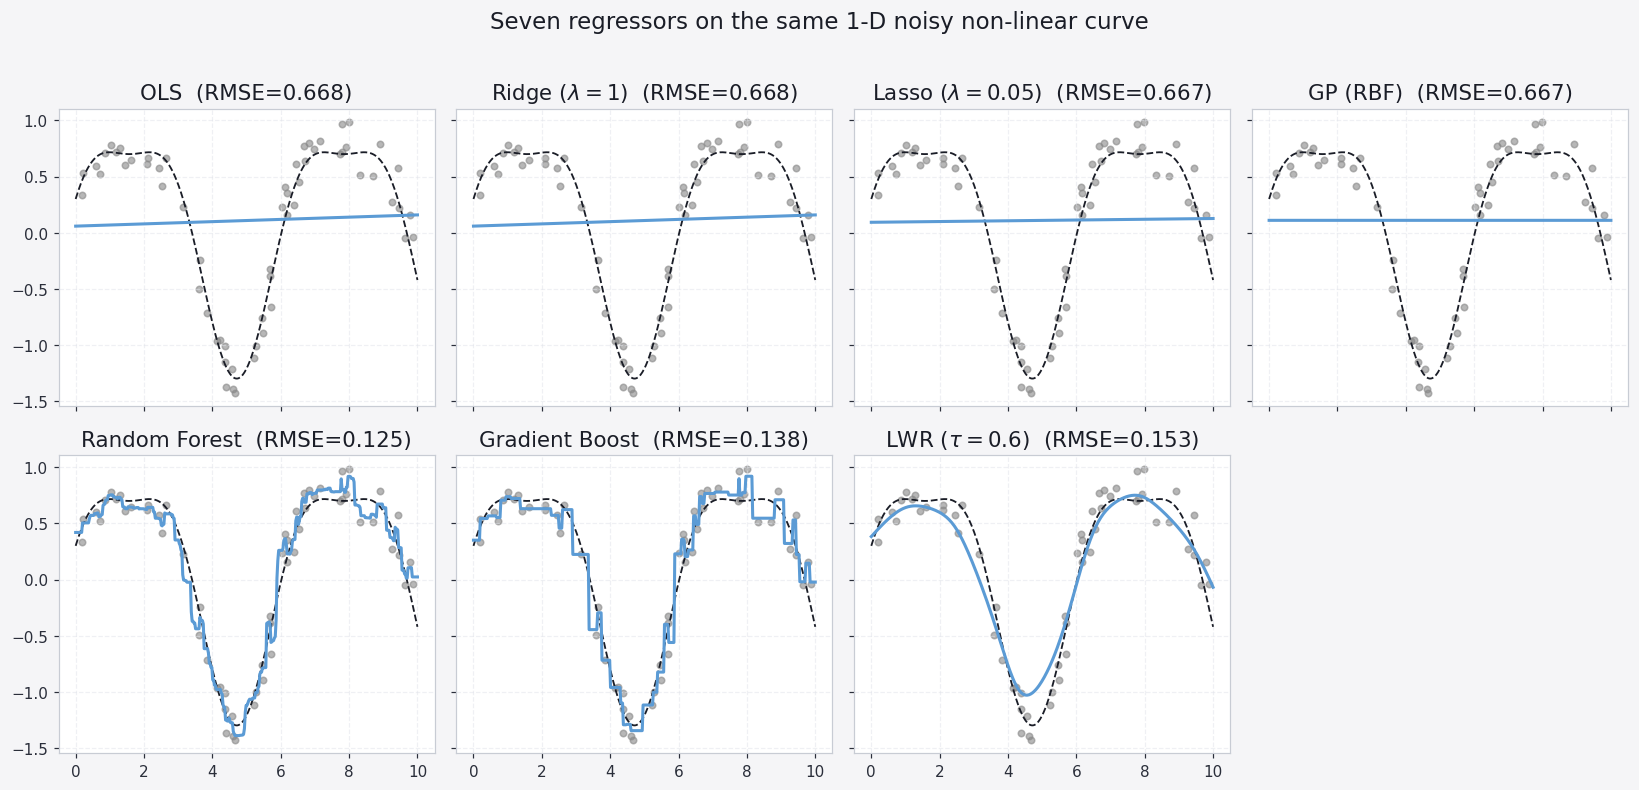

In [3]:
# Head-to-head on a non-linear noisy 1-D problem
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(0)
X_tr = np.sort(rng.uniform(0, 10, 60))[:, None]
y_tr = np.sin(X_tr.ravel()) + 0.3*np.cos(2*X_tr.ravel()) + 0.15*rng.randn(60)
X_te = np.linspace(0, 10, 400)[:, None]
y_te = np.sin(X_te.ravel()) + 0.3*np.cos(2*X_te.ravel())

def lwr_predict(x_q, X, y, tau=0.6):
    out = []
    for q in x_q.ravel():
        w = np.exp(-((X.ravel()-q)**2)/(2*tau**2))
        Xb = np.c_[np.ones_like(X.ravel()), X.ravel()]
        W  = np.diag(w)
        theta = np.linalg.pinv(Xb.T@W@Xb) @ Xb.T @ W @ y
        out.append(theta[0] + theta[1]*q)
    return np.array(out)

models = {
    'OLS'             : LinearRegression().fit(X_tr, y_tr),
    'Ridge ($\\lambda=1$)' : Ridge(alpha=1).fit(X_tr, y_tr),
    'Lasso ($\\lambda=0.05$)': Lasso(alpha=0.05).fit(X_tr, y_tr),
    'GP (RBF)'        : GaussianProcessRegressor(kernel=C(1.0)*RBF(1.0), normalize_y=True).fit(X_tr, y_tr),
    'Random Forest'   : RandomForestRegressor(n_estimators=200, random_state=0).fit(X_tr, y_tr),
    'Gradient Boost'  : GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0).fit(X_tr, y_tr),
}

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
axes = axes.ravel()
named = list(models.items()) + [('LWR ($\\tau=0.6$)', None)]

for ax, (name, m) in zip(axes, named):
    ax.scatter(X_tr, y_tr, s=18, color='#888', alpha=0.6, label='train')
    ax.plot(X_te, y_te, color='#1a1d27', lw=1.2, ls='--', label='truth')
    if name.startswith('LWR'):
        y_p = lwr_predict(X_te, X_tr, y_tr, tau=0.6)
    else:
        y_p = m.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_p))
    ax.plot(X_te, y_p, color=PALETTE[0], lw=2)
    ax.set_title(f'{name}  (RMSE={rmse:.3f})')
    ax.grid(True)

axes[-1].axis('off')
fig.suptitle('Seven regressors on the same 1-D noisy non-linear curve', y=1.02, fontsize=15)
fig.tight_layout()
plt.show()


---
## What we just saw

- **OLS / Ridge / Lasso** can only bend along their basis — the line under-fits the sinusoid.
- **GP** with an RBF kernel matches the curve and gives free uncertainty bars (not shown here).
- **Tree ensembles** (RF, GB) approximate the curve with axis-aligned steps — note the **flat extrapolation** beyond the data range.
- **LWR** smoothly tracks the curve where data exists; bandwidth $\tau$ trades bias for variance.

> Lesson: there is **no free lunch**. The right regressor depends on whether you need
> uncertainty, sparsity, smoothness, extrapolation, or raw accuracy.


---
## Summary

- Each algorithm in this category attacks a **different shape of problem**.
- The decision rule above is a heuristic, not a law — always benchmark.
- Read the linked deep-dive notebook for derivations, failure modes and exercises.

> Continue to the other recap notebooks: [Regression](illustrated_00_recap_regression.ipynb) ·
> [Classification](illustrated_00_recap_classification.ipynb) ·
> [Ensembles](illustrated_00_recap_ensembles.ipynb) ·
> [Clustering](illustrated_00_recap_clustering.ipynb) ·
> [Dim. Reduction](illustrated_00_recap_dim_reduction.ipynb) ·
> [Anomaly Detection](illustrated_00_recap_anomaly_detection.ipynb) ·
> [Time Series](illustrated_00_recap_time_series.ipynb) ·
> [RL](illustrated_00_recap_reinforcement_learning.ipynb).
